**Import the libraries**

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

**Loading the dataset**

In [ ]:
# Construct the raw GitHub URL for the train.csv file
train_data_url = 'https://raw.githubusercontent.com/joyce95560/TASK-1-COM-763/main/train.csv'

# Load the train.csv data into a pandas DataFrame
df_train = pd.read_csv(train_data_url)

print('Train Data:')
display(df_train.head())

Train Data:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Summary Statistics**

In [ ]:
# Display summary statistics for numerical data only
display(df_train.describe(include=np.number))

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Display the data type of each column**

In [ ]:
# Display the data type of each column
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Save datatype**

In [ ]:
df_train_dtypes = df_train.dtypes
print("Data types of df_train saved:")
display(df_train_dtypes)

Data types of df_train saved:


,0
Id,int16
MSSubClass,int16
MSZoning,category
LotFrontage,float32
LotArea,int32
...,...
MoSold,int8
YrSold,int16
SaleType,category
SaleCondition,category


**Memory optimization**

**Check Current Memory Usage**

In [ ]:
initial_memory_usage = df_train.memory_usage(deep=True).sum()
print(f"Initial memory usage: {initial_memory_usage / (1024**2):.2f} MB")

Initial memory usage: 3.43 MB


**Optimize Numerical Columns**


In [ ]:
def optimize_numerical_columns(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        # Optimize integer columns
        if df[col].dtype == 'int64':
            min_val = df[col].min()
            max_val = df[col].max()
            if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        # Optimize float columns (handle NaNs before checking min/max for float32 conversion)
        elif df[col].dtype == 'float64':
            # Check if all non-NaN values fit into float32
            # Using .values.max() and .values.min() is more robust for floats with NaNs
            if df[col].isnull().all(): # If all values are NaN, it can be float32
                df[col] = df[col].astype(np.float32)
            else:
                non_nan_min = df[col].min()
                non_nan_max = df[col].max()
                if np.isfinite(non_nan_min) and np.isfinite(non_nan_max): # Only downcast if no inf values
                    if non_nan_min >= np.finfo(np.float32).min and non_nan_max <= np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
    return df

df_train = optimize_numerical_columns(df_train)
print("Numerical columns optimized.")

Numerical columns optimized.


**Optimize Object Columns**
Object columns that contain categorical data (i.e., a limited number of unique values) can be converted to the 'category' data type. This often leads to significant memory savings.

In [ ]:
def optimize_object_columns(df, threshold=0.5):
    for col in df.select_dtypes(include=['object']).columns:
        num_unique_values = len(df[col].unique())
        num_total_values = len(df[col])
        if (num_unique_values / num_total_values) < threshold:
            df[col] = df[col].astype('category')
    return df

df_train = optimize_object_columns(df_train)
print("Object columns optimized.")

Object columns optimized.


**Final Memory Usage after Optimization**

In [ ]:
final_memory_usage = df_train.memory_usage(deep=True).sum()
print(f"Final memory usage: {final_memory_usage / (1024**2):.2f} MB")
print(f"Memory saved: {(initial_memory_usage - final_memory_usage) / (1024**2):.2f} MB ({((initial_memory_usage - final_memory_usage) / initial_memory_usage * 100):.2f}%)")

Final memory usage: 0.18 MB
Memory saved: 3.25 MB (94.64%)


**Display optimized DataFrame info and head**

In [ ]:
df_train.info()
display(df_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int16   
 1   MSSubClass     1460 non-null   int16   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float32 
 4   LotArea        1460 non-null   int32   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   in

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Checking for missing values**

In [ ]:
missing_values = df_train.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with missing values and their counts:")
display(missing_values)

Columns with missing values and their counts:


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


### Handling Missing Values for `PoolQC` and `MiscFeature`
Given that `PoolQC` and `MiscFeature` have a very large number of missing values, it's reasonable to assume that `NaN` in these columns signifies the *absence* of a pool or a miscellaneous feature, respectively. Therefore, we will impute these missing values with the string 'None' (or 'No'), treating 'None' as a distinct category.

In [ ]:
# Add 'None' as a category to the 'PoolQC' and 'MiscFeature' columns
df_train['PoolQC'] = df_train['PoolQC'].cat.add_categories('None')
df_train['MiscFeature'] = df_train['MiscFeature'].cat.add_categories('None')

# Impute 'PoolQC' and 'MiscFeature' with 'None'
df_train['PoolQC'] = df_train['PoolQC'].fillna('None')
df_train['MiscFeature'] = df_train['MiscFeature'].fillna('None')

print("Missing values in 'PoolQC' and 'MiscFeature' have been imputed with 'None'.")

# Verify the changes
print("Remaining missing values for 'PoolQC' and 'MiscFeature':")
display(df_train[['PoolQC', 'MiscFeature']].isnull().sum())

Missing values in 'PoolQC' and 'MiscFeature' have been imputed with 'None'.
Remaining missing values for 'PoolQC' and 'MiscFeature':


,0
PoolQC,0
MiscFeature,0


**Exploratory Data Analysis**

## Visualizing Distribution of Numerical Features

To understand the spread, central tendency, and potential outliers of numerical data, we will visualize their distributions using histograms and box plots.

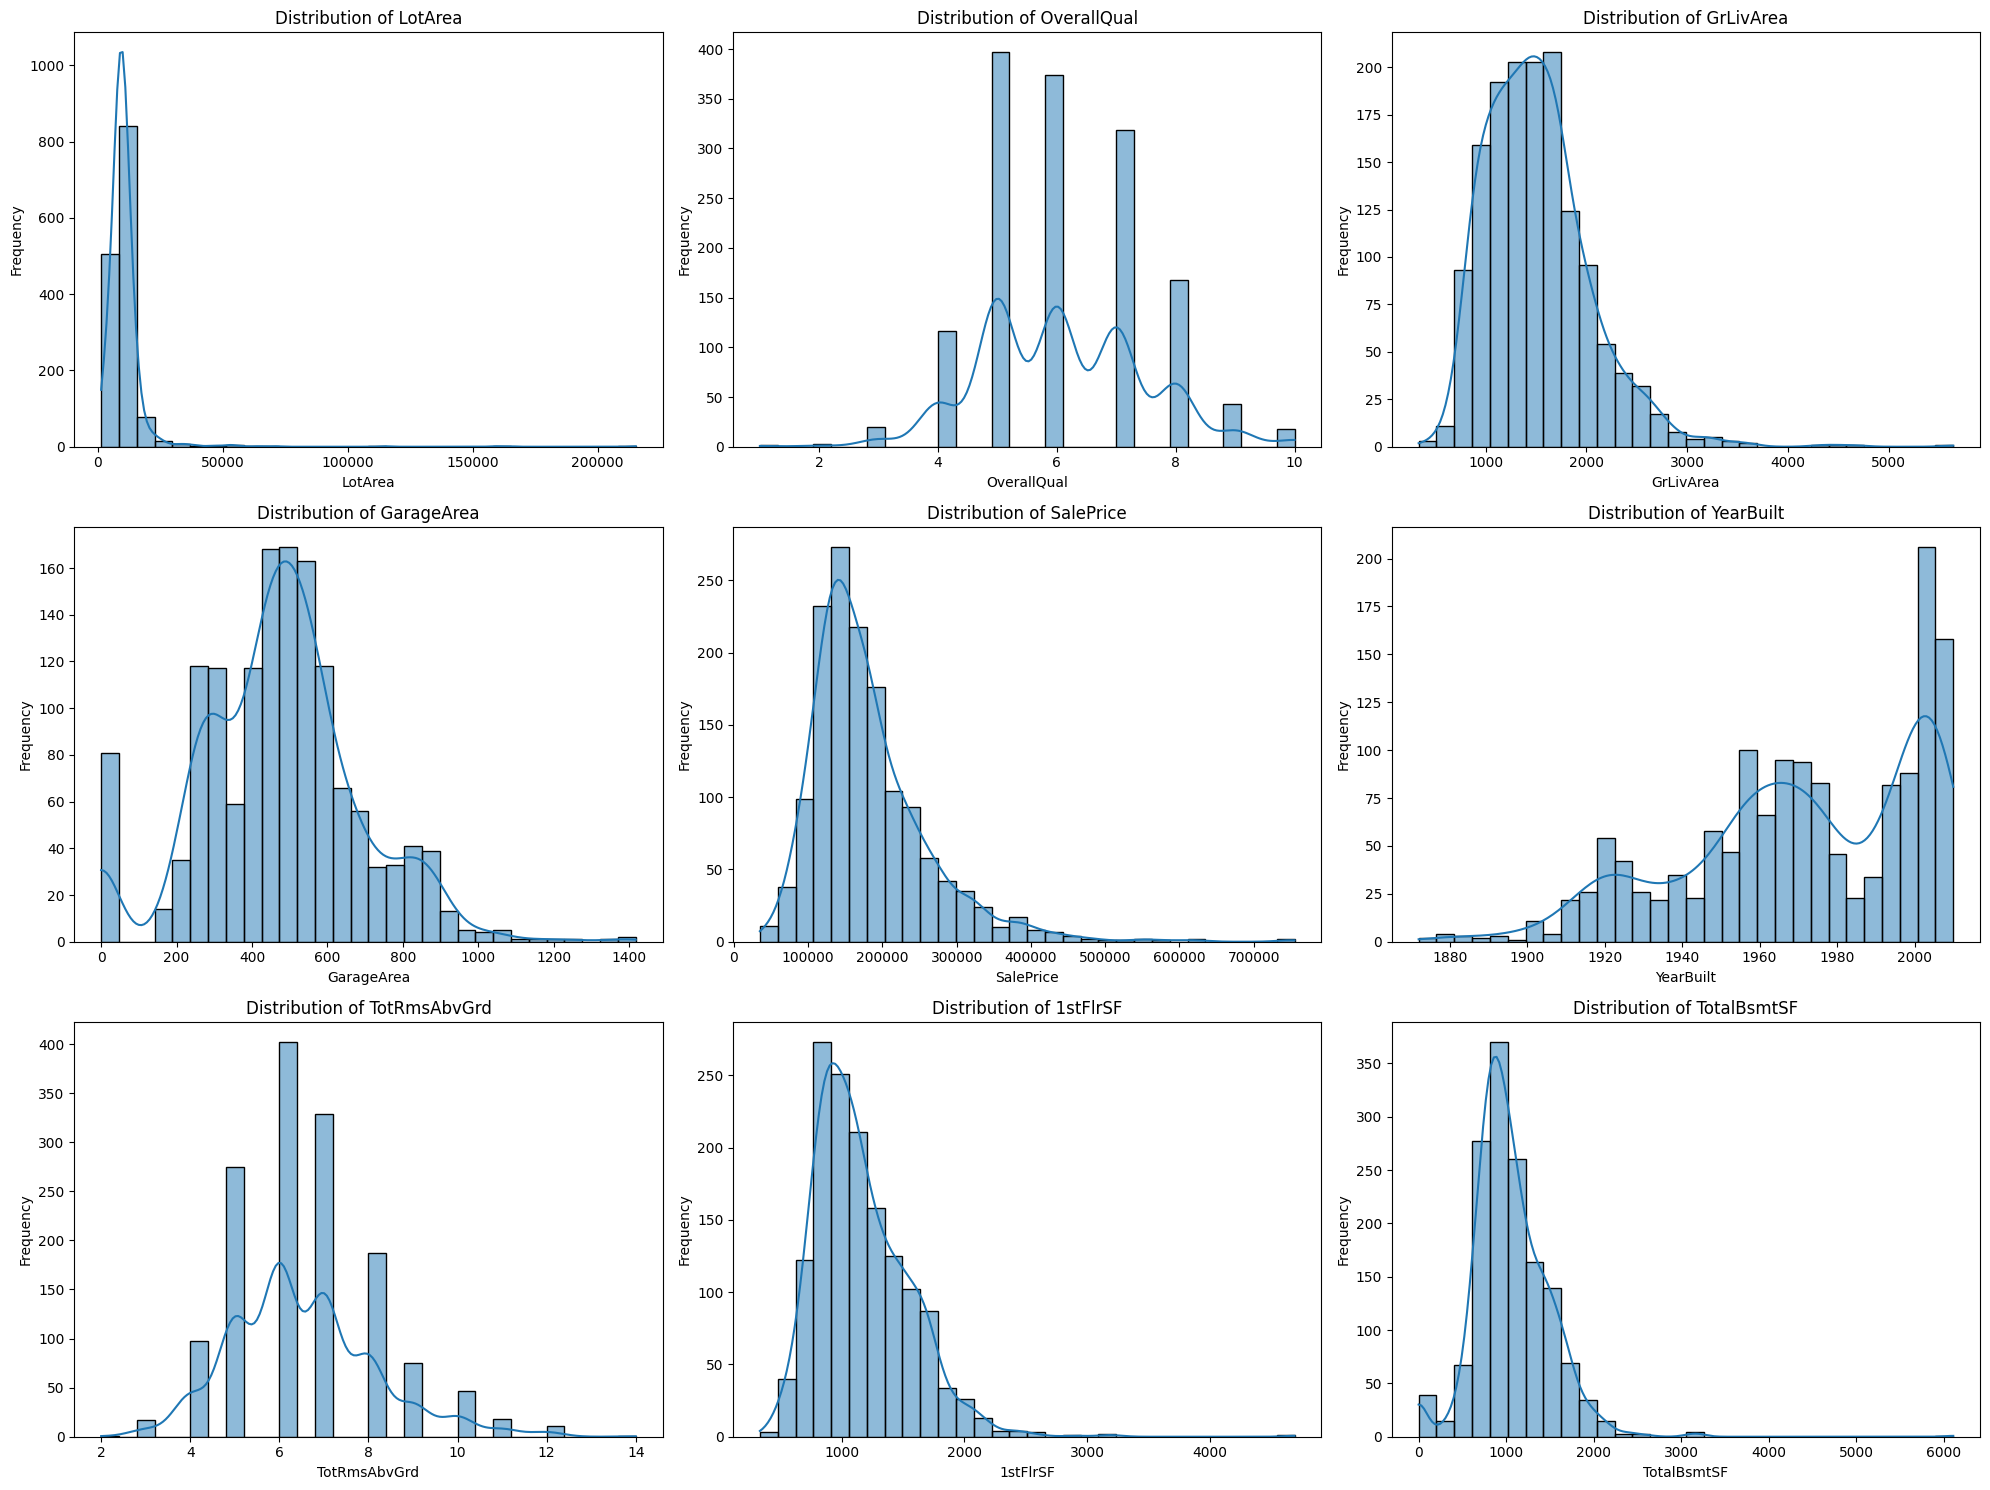

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for visualization (excluding 'Id' and potentially others that are identifiers or not truly numerical)
numerical_cols = df_train.select_dtypes(include=['int8', 'int16', 'int32', 'float32']).columns.tolist()

# Exclude 'Id' as it's an identifier and not a feature for distribution analysis
if 'Id' in numerical_cols:
    numerical_cols.remove('Id')

# Let's visualize a subset of these columns to start
# You can modify this list to include more or different columns
selected_numerical_cols = ['LotArea', 'OverallQual', 'GrLivArea', 'GarageArea', 'SalePrice', 'YearBuilt', 'TotRmsAbvGrd', '1stFlrSF', 'TotalBsmtSF']

plt.figure(figsize=(20, 15))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.histplot(df_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Box Plots for Numerical Features

Box plots provide a good summary of the five-number summary (minimum, first quartile, median, third quartile, and maximum) and can help identify outliers.

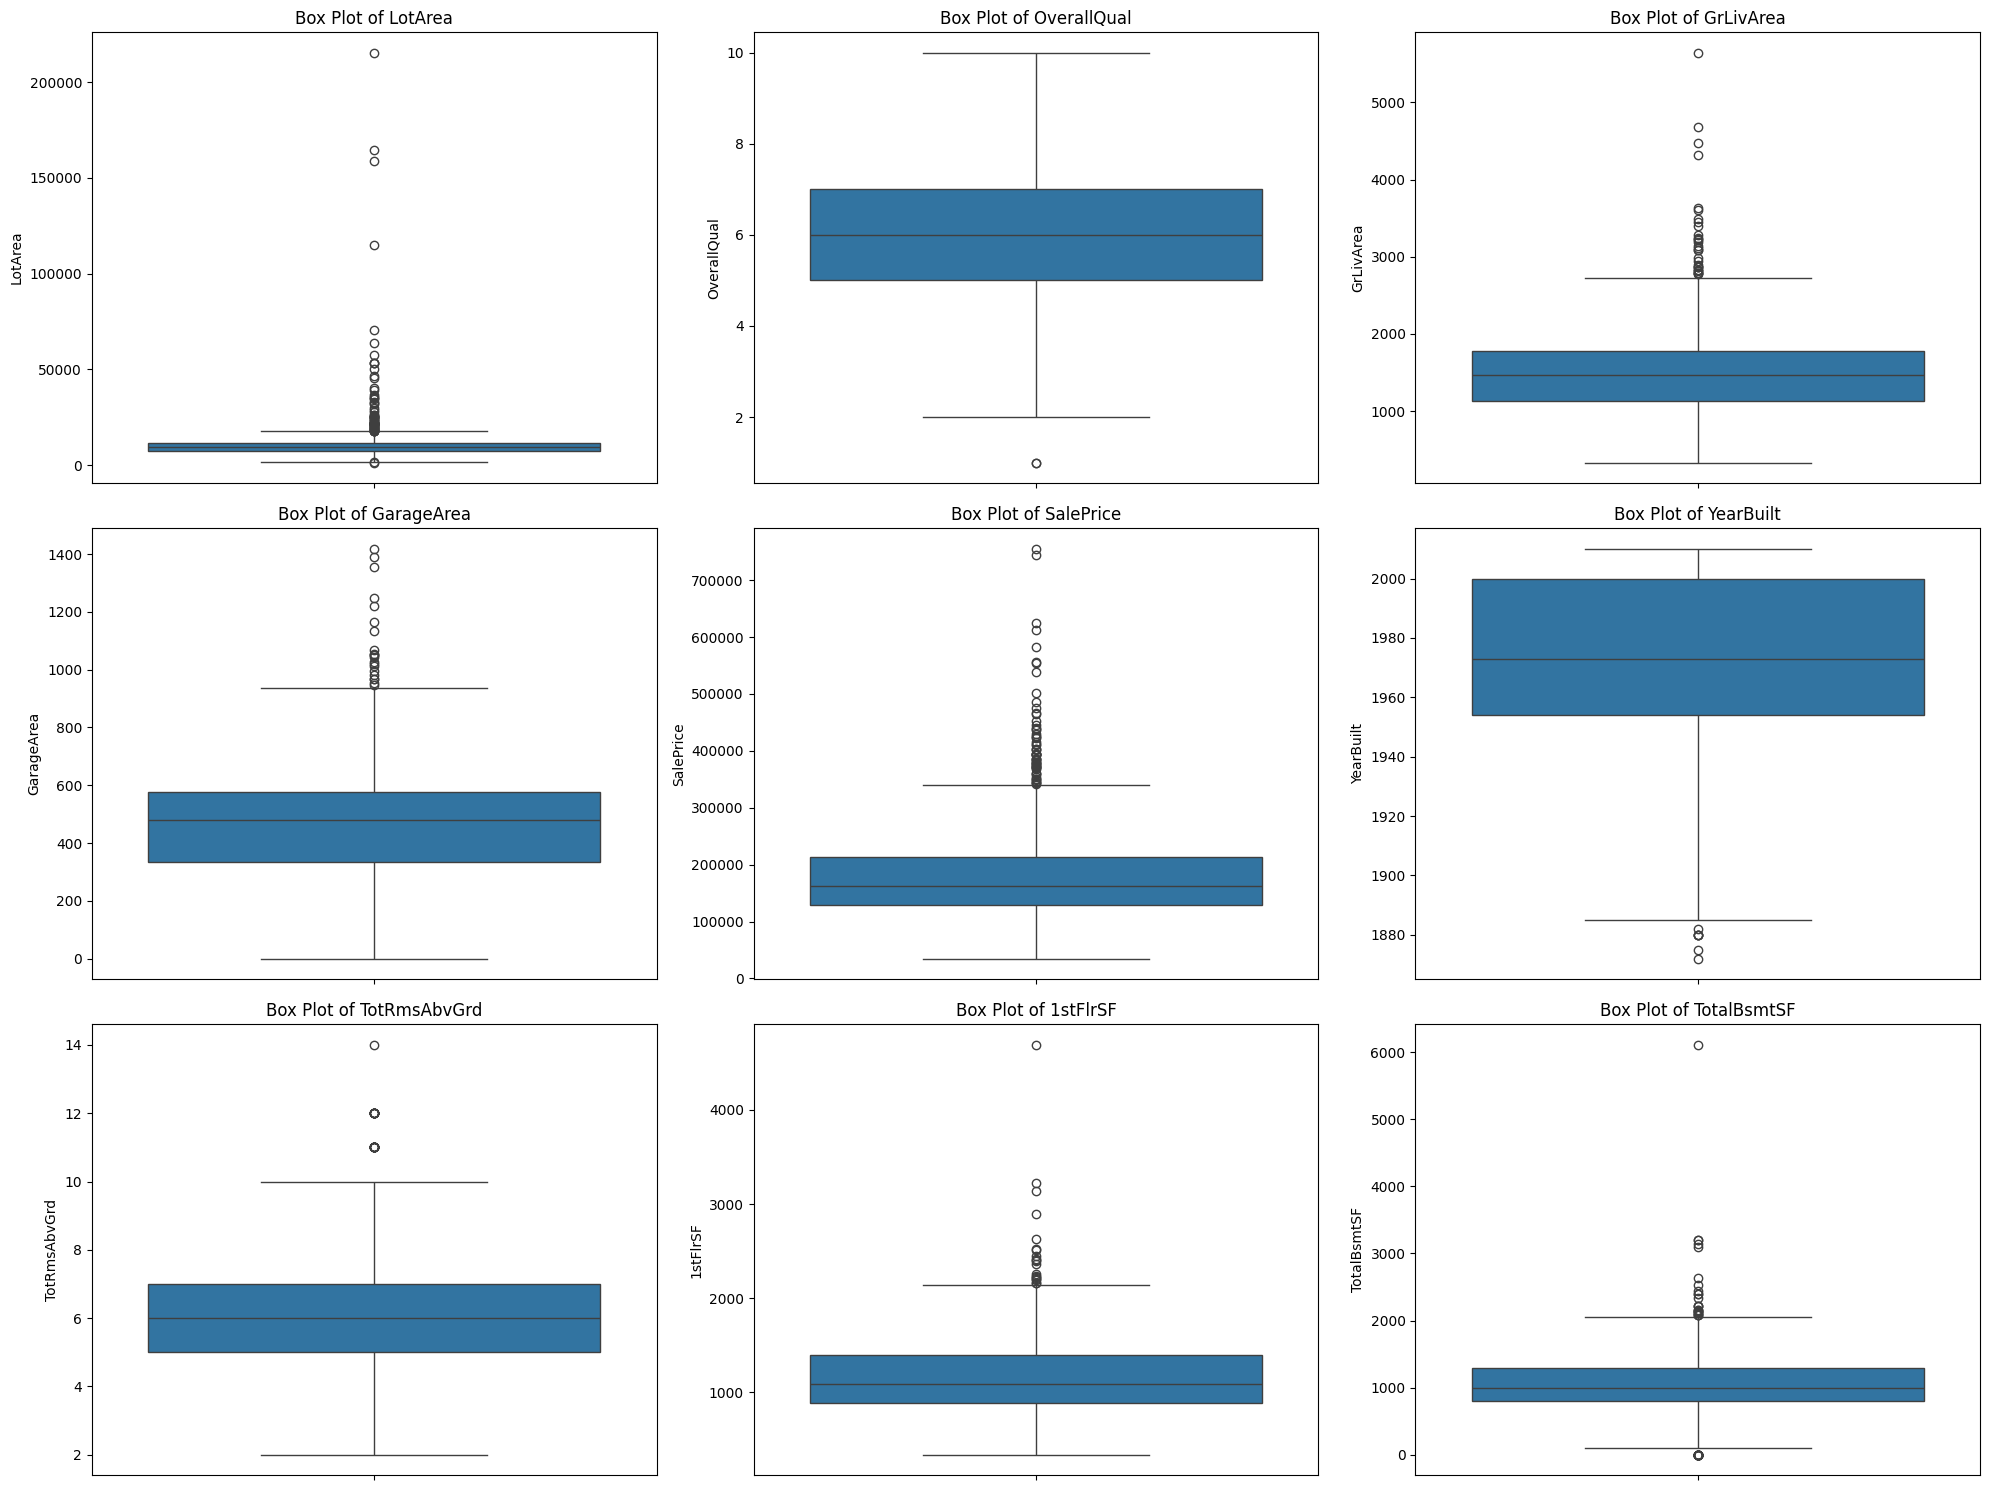

In [ ]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.boxplot(y=df_train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Correlation heatmap**

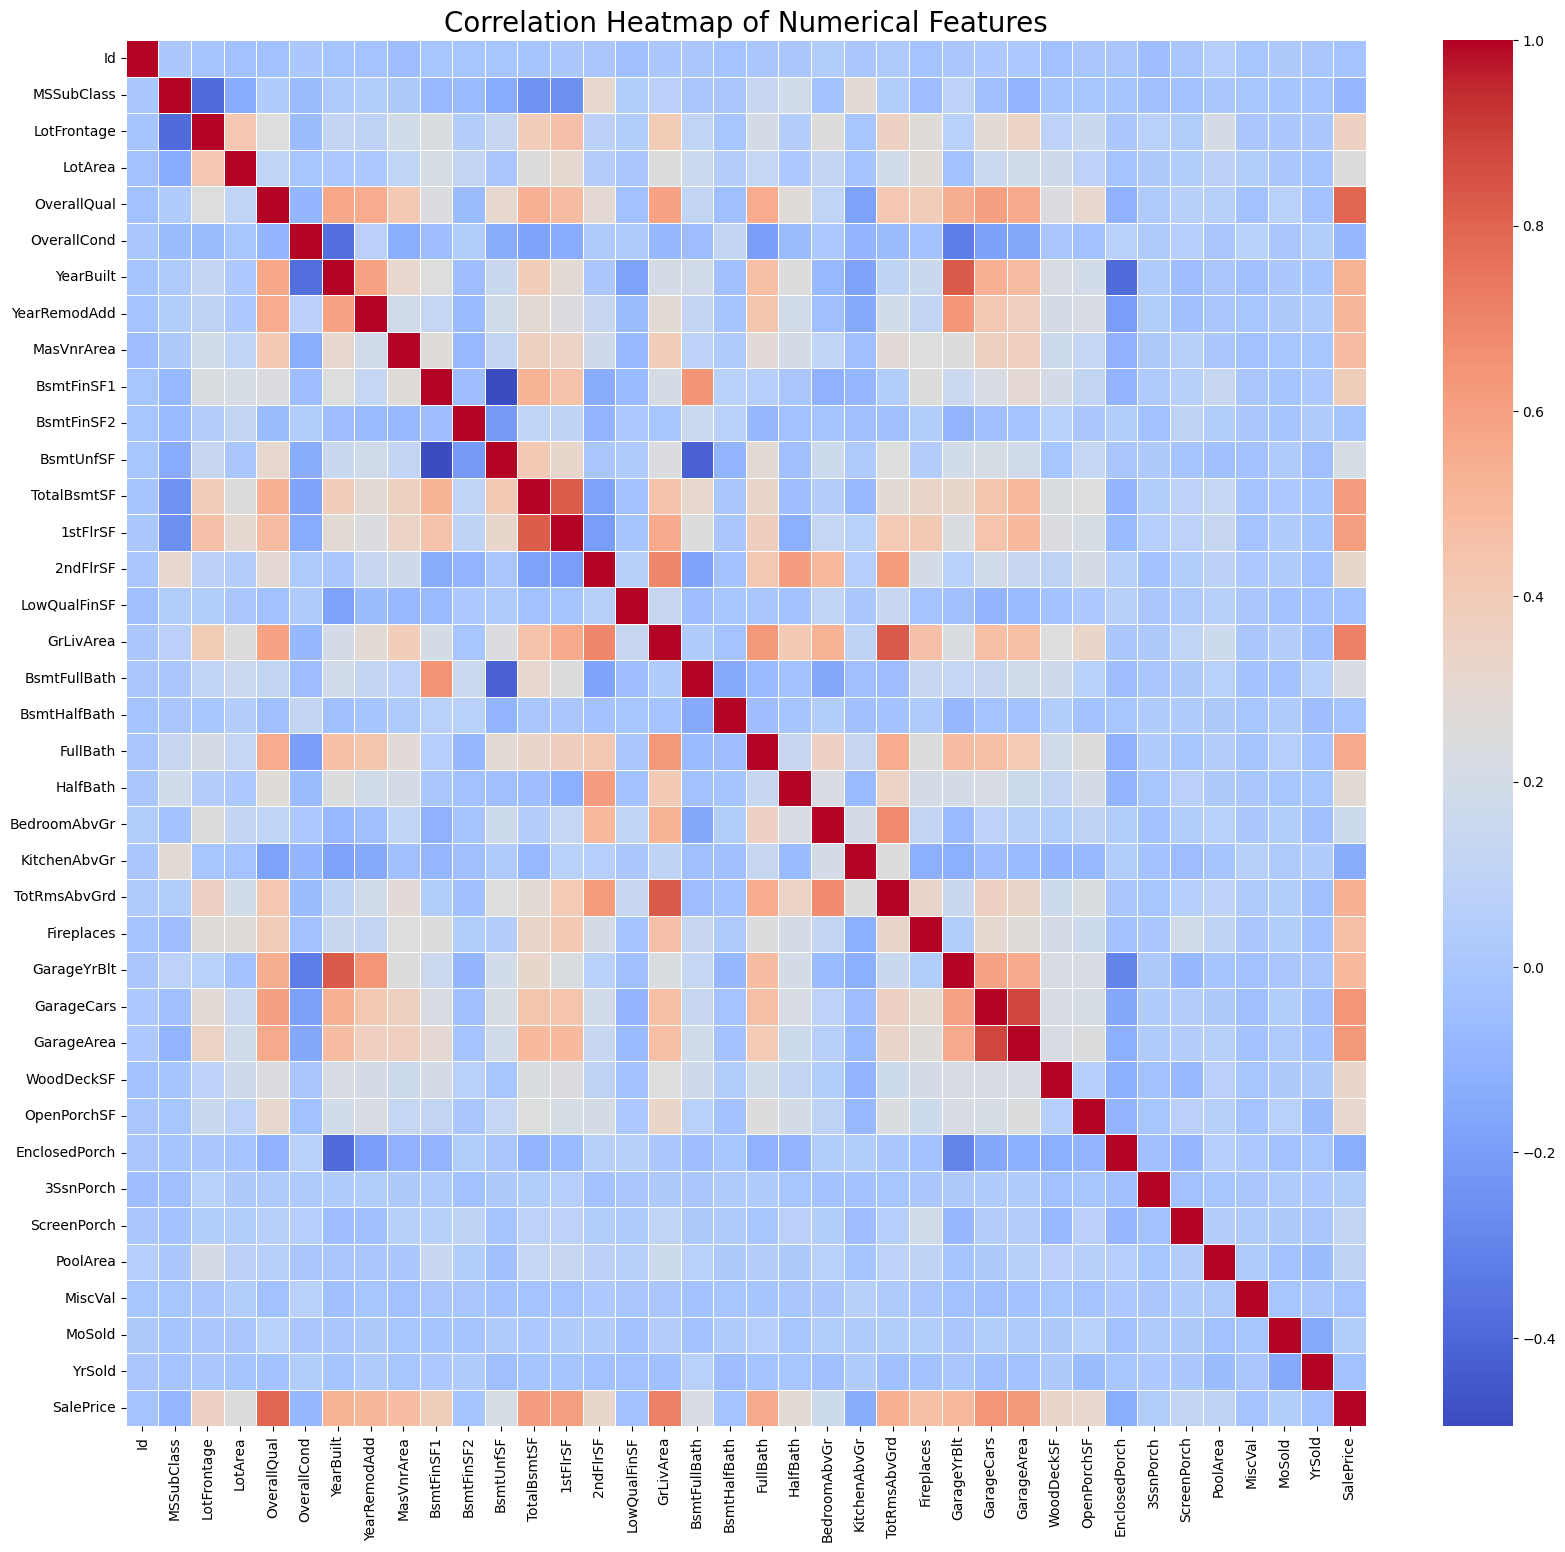

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df_train.select_dtypes(include=['int8', 'int16', 'int32', 'float32'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.show()

**Handling Outliers**

**Calculate IQR and Filter Outliers**



In [ ]:
print(f"Original DataFrame shape: {df_train.shape}")

# Select numerical columns for outlier detection (excluding 'Id' and categorical converted numericals)
numerical_cols_for_outliers = df_train.select_dtypes(include=['int8', 'int16', 'int32', 'float32']).columns.tolist()

# Exclude 'Id' as it's an identifier
if 'Id' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('Id')

# Define a list of columns for which we want to detect and remove outliers.
# It's good practice to be selective, as some 'outliers' might be meaningful data points.
# For this task, we will consider the 'selected_numerical_cols' that were previously used for visualization.
# You can modify this list based on domain knowledge.
outlier_columns = [col for col in selected_numerical_cols if col in numerical_cols_for_outliers]

# Create a copy to work with, so the original df_train is not immediately modified if unintended
df_train_cleaned = df_train.copy()

# Loop through each selected column to detect and remove outliers
for col in outlier_columns:
    Q1 = df_train_cleaned[col].quantile(0.25)
    Q3 = df_train_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    df_train_cleaned = df_train_cleaned[(df_train_cleaned[col] >= lower_bound) & (df_train_cleaned[col] <= upper_bound)]

    print(f"Outliers removed for column '{col}'. Remaining shape: {df_train_cleaned.shape}")

print(f"\nDataFrame shape after outlier removal: {df_train_cleaned.shape}")


Original DataFrame shape: (1460, 81)
Outliers removed for column 'LotArea'. Remaining shape: (1391, 81)
Outliers removed for column 'OverallQual'. Remaining shape: (1389, 81)
Outliers removed for column 'GrLivArea'. Remaining shape: (1361, 81)
Outliers removed for column 'GarageArea'. Remaining shape: (1352, 81)
Outliers removed for column 'SalePrice'. Remaining shape: (1298, 81)
Outliers removed for column 'YearBuilt'. Remaining shape: (1293, 81)
Outliers removed for column 'TotRmsAbvGrd'. Remaining shape: (1285, 81)
Outliers removed for column '1stFlrSF'. Remaining shape: (1272, 81)
Outliers removed for column 'TotalBsmtSF'. Remaining shape: (1235, 81)

DataFrame shape after outlier removal: (1235, 81)


**df_train_cleaned no outliers**

In [ ]:
display(df_train_cleaned.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,None,NaN,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,None,NaN,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,None,NaN,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,None,NaN,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,None,NaN,None,0,12,2008,WD,Normal,250000


**Box Plots for Outlier Detection (After Cleaning)**

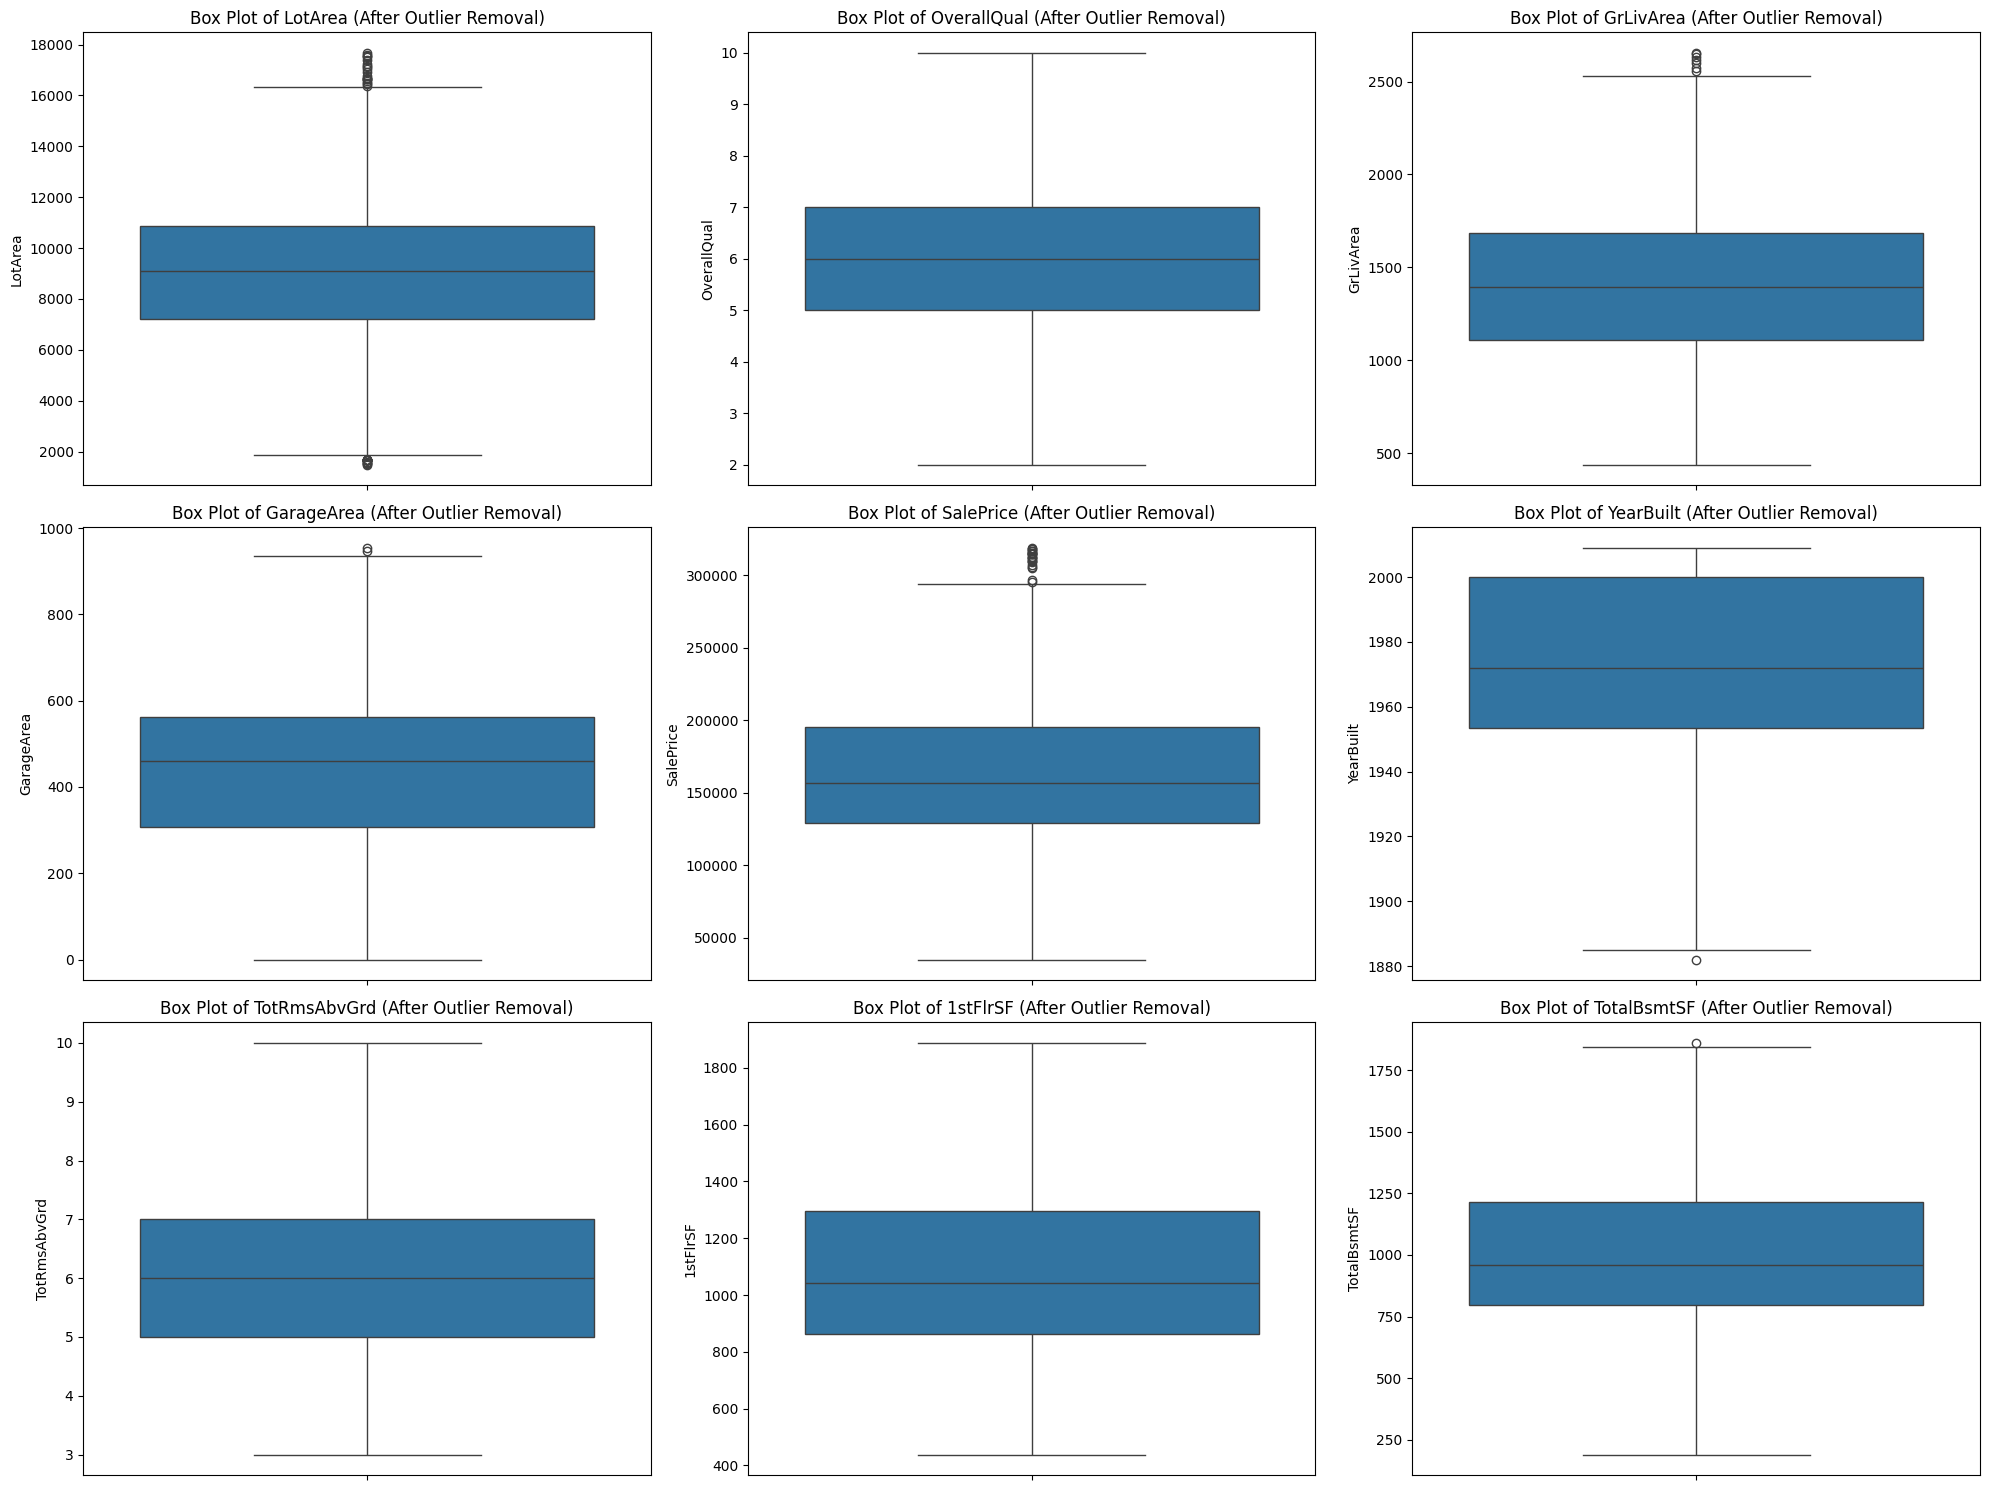

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'selected_numerical_cols' is already defined from previous steps
# If not, you would define it here, e.g.:
# selected_numerical_cols = ['LotArea', 'OverallQual', 'GrLivArea', 'GarageArea', 'SalePrice', 'YearBuilt', 'TotRmsAbvGrd', '1stFlrSF', 'TotalBsmtSF']

plt.figure(figsize=(20, 15))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid (adjust grid size if 'selected_numerical_cols' changes)
    sns.boxplot(y=df_train_cleaned[col]) # Plotting from the cleaned DataFrame
    plt.title(f'Box Plot of {col} (After Outlier Removal)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Feature Engineering**

In [ ]:
# Create an explicit copy of the cleaned DataFrame for feature engineering
df_fe = df_train_cleaned.copy()

print("Created df_fe for feature engineering.")
display(df_fe.head())

Created df_fe for feature engineering.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,None,NaN,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,None,NaN,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,None,NaN,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,None,NaN,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,None,NaN,None,0,12,2008,WD,Normal,250000


**Scaling the data**

**Scaling Numerical Features**



In [ ]:
# Select numerical columns for scaling
numerical_cols_to_scale = df_fe.select_dtypes(include=['int8', 'int16', 'int32', 'float32']).columns.tolist()

# Exclude 'Id' and 'SalePrice' from scaling
if 'Id' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('Id')
if 'SalePrice' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('SalePrice')

print(f"Numerical columns selected for scaling: {numerical_cols_to_scale}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical columns
df_fe[numerical_cols_to_scale] = scaler.fit_transform(df_fe[numerical_cols_to_scale])

print("Numerical columns scaled successfully.")

# Display the head of the DataFrame with scaled values and descriptive statistics for a few scaled columns
display(df_fe.head())
display(df_fe[numerical_cols_to_scale].describe())

Numerical columns selected for scaling: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Numerical columns scaled successfully.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,0.059775,RL,-0.101555,-0.179527,Pave,NaN,Reg,Lvl,AllPub,...,-0.040205,None,NaN,None,-0.077926,-1.598654,0.149714,WD,Normal,208500
1,2,-0.870265,RL,0.636543,0.186995,Pave,NaN,Reg,Lvl,AllPub,...,-0.040205,None,NaN,None,-0.077926,-0.484468,-0.604968,WD,Normal,181500
2,3,0.059775,RL,0.046065,0.712874,Pave,NaN,IR1,Lvl,AllPub,...,-0.040205,None,NaN,None,-0.077926,1.001113,0.149714,WD,Normal,223500
3,4,0.292285,RL,-0.347587,0.171059,Pave,NaN,IR1,Lvl,AllPub,...,-0.040205,None,NaN,None,-0.077926,-1.598654,-1.359650,WD,Abnorml,140000
4,5,0.059775,RL,0.833369,1.672205,Pave,NaN,IR1,Lvl,AllPub,...,-0.040205,None,NaN,None,-0.077926,2.115299,0.149714,WD,Normal,250000


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1.235000e+03,1.018000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.229000e+03,1.235000e+03,1.235000e+03,...,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03,1.235000e+03
mean,-4.890375e-17,2.442927e-17,1.553413e-16,-1.503071e-16,1.826699e-16,3.820246e-15,2.970184e-15,2.023515e-17,2.589022e-17,1.222594e-17,...,-8.054735e-17,3.739699e-17,-1.869849e-17,-1.869849e-17,2.013684e-17,5.753382e-18,1.438346e-17,4.315037e-18,5.465713e-17,5.214291e-14
std,1.000405e+00,1.000492e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000407e+00,1.000405e+00,1.000405e+00,...,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00,1.000405e+00
min,-8.702648e-01,-2.266641e+00,-2.397462e+00,-3.310422e+00,-3.300807e+00,-3.002568e+00,-1.669889e+00,-5.659937e-01,-1.059679e+00,-2.945118e-01,...,-2.328620e+00,-7.417557e-01,-7.106650e-01,-3.725063e-01,-1.042493e-01,-2.740347e-01,-4.020519e-02,-7.792637e-02,-1.970049e+00,-1.359650e+00
25%,-8.702648e-01,-4.952069e-01,-5.768048e-01,-8.063156e-01,-5.636785e-01,-5.855107e-01,-8.923728e-01,-5.659937e-01,-1.059679e+00,-2.945118e-01,...,-7.227334e-01,-7.417557e-01,-7.106650e-01,-3.725063e-01,-1.042493e-01,-2.740347e-01,-4.020519e-02,-7.792637e-02,-4.844679e-01,-6.049679e-01
50%,-1.727351e-01,-3.141869e-03,2.763759e-02,2.838663e-02,-5.636785e-01,3.988168e-02,4.196855e-01,-5.659937e-01,-8.140258e-02,-2.945118e-01,...,7.499598e-02,-7.417557e-01,-3.557772e-01,-3.725063e-01,-1.042493e-01,-2.740347e-01,-4.020519e-02,-7.792637e-02,-1.130726e-01,1.497143e-01
75%,2.922847e-01,5.873361e-01,5.871412e-01,8.630889e-01,3.486976e-01,9.864216e-01,9.056331e-01,3.307290e-01,6.846555e-01,-2.945118e-01,...,6.068156e-01,6.248004e-01,3.539984e-01,-3.725063e-01,-1.042493e-01,-2.740347e-01,-4.020519e-02,-7.792637e-02,6.297181e-01,9.043965e-01
max,3.082404e+00,5.655606e+00,2.759341e+00,3.367196e+00,3.085826e+00,1.290667e+00,1.245796e+00,9.983685e+00,3.096703e+00,7.058088e+00,...,2.645457e+00,5.623974e+00,8.127731e+00,5.229108e+00,1.821105e+01,7.225652e+00,2.624690e+01,3.300932e+01,2.115299e+00,1.659079e+00


**Box Plots for Numerical Features After Scaling**


**Splitting Data into Training and Testing Sets**



In [ ]:
# Define features (X) and target (y)
X = df_fe.drop('SalePrice', axis=1)
y = df_fe['SalePrice']

# Split the data into training and testing sets
# We use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (988, 286)
X_test shape: (247, 286)
y_train shape: (988,)
y_test shape: (247,)


**Handling Categorical Features**



In [ ]:
# Select categorical columns for one-hot encoding
categorical_cols = df_fe.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Categorical columns selected for One-Hot Encoding: {categorical_cols}")

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply OneHotEncoder to the selected categorical columns
categorical_encoded = ohe.fit_transform(df_fe[categorical_cols])

# Create a DataFrame from the encoded features
categorical_encoded_df = pd.DataFrame(categorical_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=df_fe.index)

# Drop the original categorical columns from df_fe
df_fe = df_fe.drop(columns=categorical_cols)

# Concatenate the one-hot encoded DataFrame with the original DataFrame
df_fe = pd.concat([df_fe, categorical_encoded_df], axis=1)

print("Categorical columns have been One-Hot Encoded successfully.")

# Display the head of the DataFrame with encoded values and its info
display(df_fe.head())
df_fe.info()

Categorical columns selected for One-Hot Encoding: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Categorical columns have been One-Hot Encoded successfully.


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.059775,-0.101555,-0.179527,0.863089,-0.563678,1.087837,0.905633,0.726342,0.767473,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,-0.870265,0.636543,0.186995,0.028387,2.173450,0.175102,-0.406425,-0.565994,1.471418,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,0.059775,0.046065,0.712874,0.863089,-0.563678,1.020227,0.857038,0.502161,0.198105,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,0.292285,-0.347587,0.171059,0.863089,-0.563678,-1.887003,-0.697994,-0.565994,-0.500664,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,0.059775,0.833369,1.672205,1.697791,-0.563678,0.986422,0.759849,1.741749,0.635483,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 1235 entries, 0 to 1459
Columns: 287 entries, Id to SaleCondition_Partial
dtypes: float64(285), int16(1), int32(1)
memory usage: 2.7 MB


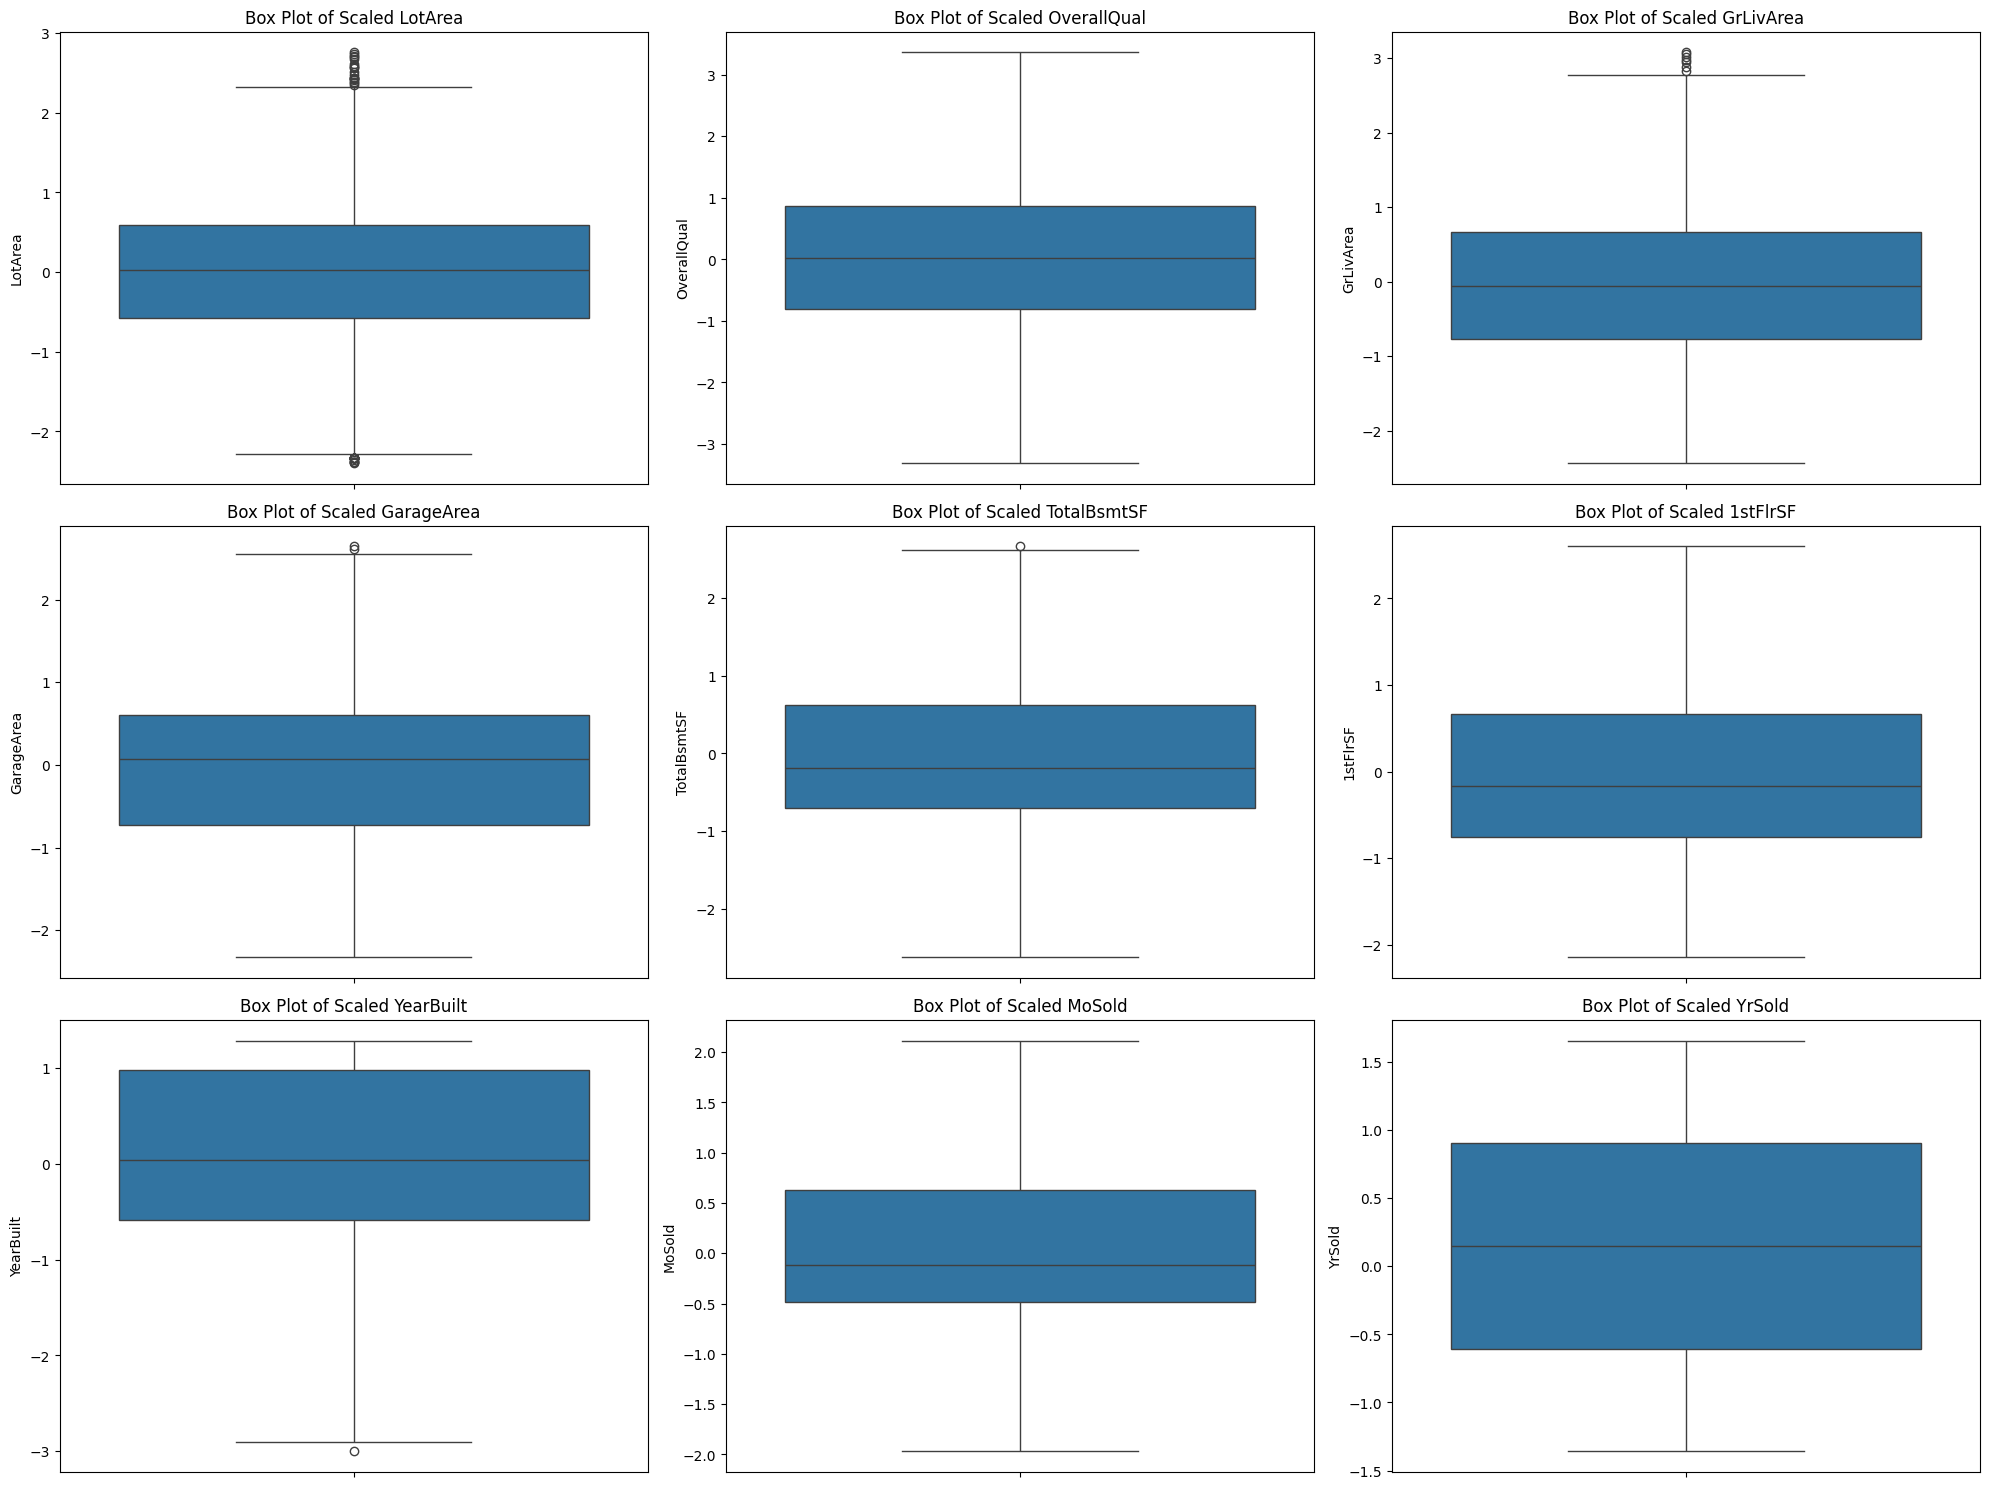

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse the list of numerical columns that were scaled
# numerical_cols_to_scale was defined in the previous step

# For visualization purposes, let's select a few representative scaled columns
# as plotting all 36 scaled columns in one go might be overwhelming.
# You can adjust this list as needed.
selected_scaled_cols_for_plot = ['LotArea', 'OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'MoSold', 'YrSold']

plt.figure(figsize=(20, 15))
for i, col in enumerate(selected_scaled_cols_for_plot):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.boxplot(y=df_fe[col])
    plt.title(f'Box Plot of Scaled {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Model linear regression**

**Build and Evaluate a Linear Regression Model**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Re-define features (X) and target (y) from df_train_cleaned
# df_train_cleaned is the DataFrame after outlier removal but before manual scaling/encoding
X = df_train_cleaned.drop('SalePrice', axis=1)
y = df_train_cleaned['SalePrice']

# Split the data into training and testing sets for the pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical and categorical columns from the (new) X_train
numerical_cols_for_pipeline = X_train.select_dtypes(include=['int8', 'int16', 'int32', 'float32']).columns.tolist()
categorical_cols_for_pipeline = X_train.select_dtypes(include=['category', 'object']).columns.tolist() # Include 'object' in case some weren't converted to category

# Exclude 'Id' from numerical columns as it's an identifier, not a feature to be scaled or imputed
if 'Id' in numerical_cols_for_pipeline:
    numerical_cols_for_pipeline.remove('Id')

print(f"Numerical columns for pipeline preprocessing: {numerical_cols_for_pipeline}")
print(f"Categorical columns for pipeline preprocessing: {categorical_cols_for_pipeline}")

# Create preprocessing steps for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Impute NaNs with mean
    ('scaler', StandardScaler())                 # Scale numerical features
])

# Create preprocessing steps for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute NaNs with most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore'))   # One-hot encode categorical features
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols_for_pipeline),
        ('cat', categorical_transformer, categorical_cols_for_pipeline)
    ],
    remainder='passthrough' # Keep other columns if any, though 'Id' was removed from X.
)

# Create the full pipeline
linear_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("\nLinear Regression pipeline created.")

# Fit the pipeline on the training data
linear_regression_pipeline.fit(X_train, y_train)

print("Linear Regression pipeline fitted successfully.")

# Make predictions on the test set using the fitted pipeline
y_pred = linear_regression_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"\nPipeline Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Numerical columns for pipeline preprocessing: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical columns for pipeline preprocessing: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Kit

Visualize Predictions vs. Actual Values


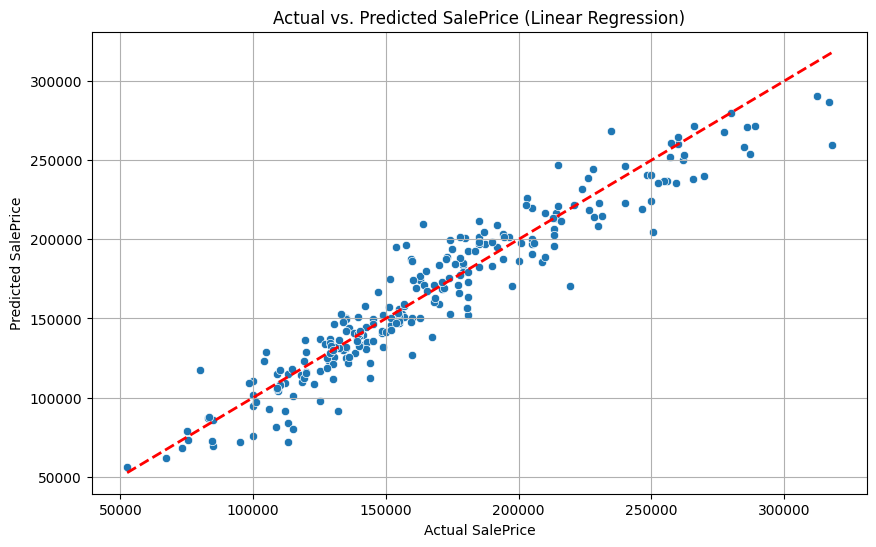

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line of perfect prediction
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs. Predicted SalePrice (Linear Regression)")
plt.grid(True)
plt.show()

**Save Best Model for Streamlit Deployment**

### Save the Trained Linear Regression Model

To deploy the trained model in a Streamlit application, we need to save it to a file. We'll use the `joblib` library for this purpose, which is efficient for saving and loading scikit-learn models.

In [ ]:
import joblib

# Define the filename for the saved pipeline model
pipeline_model_filename = 'linear_regression_pipeline_model.joblib'

# Save the trained linear_regression_pipeline to the file
joblib.dump(linear_regression_pipeline, pipeline_model_filename)

print(f"Trained Linear Regression pipeline model saved successfully as '{pipeline_model_filename}'")

Trained Linear Regression pipeline model saved successfully as 'linear_regression_pipeline_model.joblib'


In [ ]:
import joblib
from sklearn.metrics import r2_score

# 1. Fit and Predict using only the Linear Regression pipeline
# Using the already defined 'linear_regression_pipeline' from the notebook
linear_regression_pipeline.fit(X_train, y_train)
preds = linear_regression_pipeline.predict(X_test)

# 2. Evaluate performance
score = r2_score(y_test, preds)

# 3. Save the model to a file
# Using the requested filename 'linear_regression_model.pkl'
joblib.dump(linear_regression_pipeline, 'linear_regression_model.pkl')

print("Linear Regression Analysis Complete")
print("-" * 30)
print(f"R² Score: {score:.4f}")
print("Model saved to: linear_regression_model.pkl")

Linear Regression Analysis Complete
------------------------------
R² Score: 0.9049
Model saved to: linear_regression_model.pkl


**Part 2 : Deploying the model in Streamlit**

**app.py**

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained pipeline model
# Ensure this path is correct relative to where you deploy your Streamlit app
@st.cache_resource
def load_model():
    try:
        model = joblib.load('linear_regression_pipeline_model.joblib')
        return model
    except FileNotFoundError:
        st.error("Model file 'linear_regression_pipeline_model.joblib' not found. Please ensure it's in the same directory.")
        st.stop()

pipeline = load_model()

st.title('House Price Prediction App')
st.write('Enter house features to predict its sale price.')

# Collect user input for features
# This is a simplified example; you'll need to add all features your model expects
# It's crucial that the input features match the features the model was trained on.

# Example of how to get input for numerical features
mssubclass = st.number_input('MSSubClass (e.g., 60 for 2-STORY 1946 & Newer)', min_value=20, max_value=190, value=60)
lotarea = st.number_input('LotArea (square feet)', min_value=1000, max_value=200000, value=8450)
overallqual = st.slider('OverallQual (Overall material and finish quality)', min_value=1, max_value=10, value=7)
overallcond = st.slider('OverallCond (Overall condition rating)', min_value=1, max_value=9, value=5)
yearbuilt = st.number_input('YearBuilt', min_value=1800, max_value=2023, value=2003)
yearremodadd = st.number_input('YearRemodAdd (Remodel year if different from construction year)', min_value=1950, max_value=2023, value=2003)
grlinarea = st.number_input('GrLivArea (Above grade (ground) living area square feet)', min_value=300, max_value=6000, value=1710)
garagecars = st.slider('GarageCars (Size of garage in car capacity)', min_value=0, max_value=4, value=2)
garagearea = st.number_input('GarageArea (Size of garage in square feet)', min_value=0, max_value=1500, value=548)

# For simplicity, we'll assume default/median values for other features for this example
# In a real app, you'd collect input for all relevant features or use sensible defaults

# Create a dictionary for prediction input
# You MUST include all columns that were in your X_train, even if you are using default values
# The column names and their order must match what the pipeline expects.
input_data = {
    'MSSubClass': mssubclass,
    'MSZoning': 'RL', # Example: assuming default 'RL'
    'LotFrontage': 65.0, # Example: using a typical value
    'LotArea': lotarea,
    'Street': 'Pave', # Example: assuming default 'Pave'
    'Alley': 'None', # Example: imputed 'None'
    'LotShape': 'Reg',
    'LandContour': 'Lvl',
    'Utilities': 'AllPub',
    'LotConfig': 'Inside',
    'LandSlope': 'Gtl',
    'Neighborhood': 'CollgCr',
    'Condition1': 'Norm',
    'Condition2': 'Norm',
    'BldgType': '1Fam',
    'HouseStyle': '2Story',
    'OverallQual': overallqual,
    'OverallCond': overallcond,
    'YearBuilt': yearbuilt,
    'YearRemodAdd': yearremodadd,
    'RoofStyle': 'Gable',
    'RoofMatl': 'CompShg',
    'Exterior1st': 'VinylSd',
    'Exterior2nd': 'VinylSd',
    'MasVnrType': 'None', # Example: imputed 'None'
    'MasVnrArea': 0.0, # Example: imputed 0.0
    'ExterQual': 'Gd',
    'ExterCond': 'TA',
    'Foundation': 'PConc',
    'BsmtQual': 'TA', # Example: imputed 'TA'
    'BsmtCond': 'TA', # Example: imputed 'TA'
    'BsmtExposure': 'No', # Example: imputed 'No'
    'BsmtFinType1': 'Unf', # Example: imputed 'Unf'
    'BsmtFinSF1': 0,
    'BsmtFinType2': 'Unf', # Example: imputed 'Unf'
    'BsmtFinSF2': 0,
    'BsmtUnfSF': 0,
    'TotalBsmtSF': 0,
    'Heating': 'GasA',
    'HeatingQC': 'Ex',
    'CentralAir': 'Y',
    'Electrical': 'SBrkr',
    '1stFlrSF': 856,
    '2ndFlrSF': 854,
    'LowQualFinSF': 0,
    'GrLivArea': grlinarea,
    'BsmtFullBath': 1,
    'BsmtHalfBath': 0,
    'FullBath': 2,
    'HalfBath': 1,
    'BedroomAbvGr': 3,
    'KitchenAbvGr': 1,
    'KitchenQual': 'Gd',
    'TotRmsAbvGrd': 8,
    'Functional': 'Typ',
    'Fireplaces': 0,
    'FireplaceQu': 'None', # Example: imputed 'None'
    'GarageType': 'Attchd', # Example: imputed 'Attchd'
    'GarageYrBlt': yearbuilt,
    'GarageFinish': 'RFn', # Example: imputed 'RFn'
    'GarageCars': garagecars,
    'GarageArea': garagearea,
    'GarageQual': 'TA', # Example: imputed 'TA'
    'GarageCond': 'TA', # Example: imputed 'TA'
    'PavedDrive': 'Y',
    'WoodDeckSF': 0,
    'OpenPorchSF': 0,
    'EnclosedPorch': 0,
    '3SsnPorch': 0,
    'ScreenPorch': 0,
    'PoolArea': 0,
    'PoolQC': 'None', # Example: imputed 'None'
    'Fence': 'None', # Example: imputed 'None'
    'MiscFeature': 'None', # Example: imputed 'None'
    'MiscVal': 0,
    'MoSold': 2,
    'YrSold': 2008,
    'SaleType': 'WD',
    'SaleCondition': 'Normal'
}

# Create a DataFrame from the input data
# Ensure the order of columns matches the training data
input_df = pd.DataFrame([input_data])

if st.button('Predict Sale Price'):
    try:
        # Ensure 'Id' column is handled correctly if it was in X_train but not used for prediction
        # For this example, we assume 'Id' was dropped in preprocessing or is added before prediction
        # If 'Id' was part of X_train for the pipeline, you might need to add a dummy 'Id' here.
        # Given the pipeline structure, it should handle columns it was trained on.

        # If the pipeline expects 'Id' but it's not a feature for prediction,
        # we need to ensure its presence for the ColumnTransformer and then that the regressor ignores it.
        # A simpler approach is to ensure 'Id' is dropped from X BEFORE the pipeline is defined if it's not a feature.
        # In our case, the pipeline was defined to exclude 'Id' from numerical_cols_for_pipeline, so it should be fine.

        prediction = pipeline.predict(input_df)
        st.success(f'The predicted Sale Price is: ${prediction[0]:,.2f}')
    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")

st.write("\n\n--- Developed with Streamlit --- ")


Writing app.py
